In [1]:
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as nps
from scipy.stats import ks_2samp
from ndtest import ks2d2s
from matplotlib.ticker import FuncFormatter
import numpy as np

sys.path.append(os.path.abspath("../0_UTILITY_FUNCTIONS/"))
from plotting import *
from get_LrLx_data import *
from plotting import *

In [2]:
## Get the interpolated data
df = get_all_LrLx_data(interp=True, save=False, rerun=False)

Source names:  ['1A 1744-361' '4U 1543-47' '4U 1630-47' 'Aquila X-1' 'Cen X-4' 'Cir X-1'
 'EXO 1846-031' 'GRS 1739-278' 'GRS 1915+105' 'GX 339-4' 'H1743-322'
 'IGR J17091-3624' 'MAXI J1348-630' 'MAXI J1631-479' 'MAXI J1803-298'
 'MAXI J1807+132' 'MAXI J1810-222' 'MAXI J1816-195' 'MAXI J1820+070'
 'SAX J1808.4-3658' 'SAX J1810.8-2609' 'Swift J1727.8-1613'
 'Swift J1728.9-3613' 'Swift J1842.5-1124' 'Swift J1858.6-0814'
 'XTE J1701-462']


KS test p-values: Lx=3.14447e-29, Lr=1.62216e-02, 2D=5.18054e-19
Harmonic mean p-value: 6.28894e-29
Harmonic mean p-value: 6.28894e-29


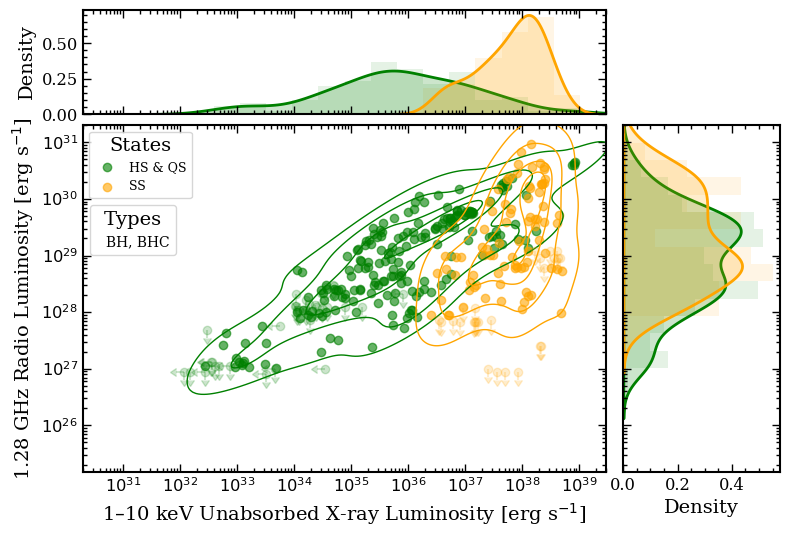

In [3]:
plot_LrLx_comparison(df, plot_type="HS_vs_SS")

---

# Dealing with multiple data points per source

This is for illustrative purposes, since Monte Carlo sampling on the p-value is not very scientific. 

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, chi2
import matplotlib.pyplot as plt


In [51]:
def summarize_pvals(pvals, name, thresholds=(0.05, 0.01, 0.001)):
    pvals = pvals[np.isfinite(pvals)]  # remove NaNs
    n = len(pvals)
    print(f"\n{name}")
    print(f"Valid iterations: {n}")

    for t in thresholds:
        frac = np.mean(pvals < t)
        print(f"Fraction with p < {t}: {100*frac:.2f}%")

    print(f"Median p-value: {np.median(pvals):.3e}")
    print(f"Mean p-value:   {np.mean(pvals):.3e}")



def repeated_random_source_sampling_ks(df, n_iter=2000, random_seed=None, plot=False):
    """
    For n_iter times:
      - randomly sample one row per unique source (column source_col)
      - apply the same masking logic as your snippet to build detection-only samples
      - compute KS p-values for log10(Lx) and log10(Lr) between group1 and group2 (detections only)
      - compute Fisher combined p-value (optional)
    Plot histograms of p-values and return arrays.

    Returns:
      dict with keys: 'pvals_Lx', 'pvals_Lr', 'pvals_fisher'
    Notes:
      - iterations where one or both groups have <2 detection points produce np.nan entries (skipped).
      - This routine uses random sampling by source to respect the source-level clustering.
    """
    rng = np.random.default_rng(random_seed)

    pvals_Lx = np.full(n_iter, np.nan)
    pvals_Lr = np.full(n_iter, np.nan)
    pvals_hmp = np.full(n_iter, np.nan)

    # Pre-cast boolean columns if necessary
    df = df.copy()


    states_group1=("HS", "QS")
    states_group2=("SS",)
    states = ("HS", "QS", "SS")
    classes_keep=("BH", "candidateBH")

    # Filter first
    df_filtered = df[df["class"].isin(classes_keep) & df["state"].isin(states) & (df["Fr_uplim_bool"] == False) & (df["Fx_uplim_bool"] == False)].copy()



    for i in range(n_iter):
        # Randomly pick one row per source
        # Using groupby + sample with a random_state makes reproducible draws, but pandas' sample RNG differs version to version.
        # Here we shuffle group keys and pick a random index from each group using numpy RNG which is stable.
        picked_indices = []
        for _, group in df_filtered.groupby("name"):
            # select one index uniformly at random
            idx = group.sample(n=1, random_state=rng.integers(0, 2**31 - 1)).index[0]
            picked_indices.append(idx)

        sampled = df_filtered.loc[picked_indices].reset_index(drop=True)

        # Build masks for the two sets
        mask1 = sampled["state"].isin(states_group1) 
        mask2 = sampled["state"].isin(states_group2) 

        # Extract detections
        x1_det = sampled.loc[mask1, "Lx"].to_numpy()
        y1_det = sampled.loc[mask1, "Lr"].to_numpy()
        x2_det = sampled.loc[mask2, "Lx"].to_numpy()
        y2_det = sampled.loc[mask2, "Lr"].to_numpy()

        # Let us require at least 5 points in each sample to run ks_2samp
        ok_Lx = (len(x1_det) >= 5) and (len(x2_det) >= 5)
        ok_Lr = (len(y1_det) >= 5) and (len(y2_det) >= 5)
        print(f"Iteration {i+1}/{n_iter}: n1_det={len(x1_det)}, n2_det={len(x2_det)}, ok_Lx={ok_Lx}, ok_Lr={ok_Lr}")


        if ok_Lx:
            log_x1_det = np.log10(x1_det)
            log_x2_det = np.log10(x2_det)
            p_Lx = ks_2samp(log_x1_det, log_x2_det).pvalue
        else:
            p_Lx = np.nan

        if ok_Lr:
            log_y1_det = np.log10(y1_det)
            log_y2_det = np.log10(y2_det)
            p_Lr = ks_2samp(log_y1_det, log_y2_det).pvalue
        else:
            p_Lr = np.nan

        # Fisher combination if both p-values are finite
        if np.isfinite(p_Lx) and np.isfinite(p_Lr):
            X = -2.0 * (np.log(p_Lx) + np.log(p_Lr))
            # df = 4 for two p-values
            p_fisher = 1.0 - chi2.cdf(X, df=4)
        else:
            p_fisher = np.nan

        # HMP combination if both p-values are finite
        if np.isfinite(p_Lx) and np.isfinite(p_Lr):
            # number of combined p-values
            k = 2.0
            # harmonic mean p-value (equal weights)
            p_hmp = k / (1.0 / p_Lx + 1.0 / p_Lr)
            # keep it in [0,1]
            p_hmp = min(max(p_hmp, 0.0), 1.0)
        else:
            p_hmp = np.nan

        
        pvals_Lx[i] = p_Lx
        pvals_Lr[i] = p_Lr
        pvals_hmp[i] = p_hmp


        if plot and ok_Lx and ok_Lr:
            print("p_Lx:", p_Lx, "p_Lr:", p_Lr, "p_hmp:", p_hmp)
            print(sampled[["name", "state", "class", "Lx", "Lr", "Fr_uplim_bool", "Fx_uplim_bool"]])
            plt.figure(figsize=(6, 4))
            plt.scatter(log_x1_det, log_y1_det, label="HS/QS", alpha=0.7)
            plt.scatter(log_x2_det, log_y2_det, label="SS", alpha=0.7)
            plt.xlabel("log10(Lx)")
            plt.ylabel("log10(Lr)")
            plt.legend()
            plt.title(f"Sampled data for iteration {i}")
            plt.show()
            

    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # Lx histogram
    axes[0].hist(pvals_Lx[~np.isnan(pvals_Lx)], bins=30)
    axes[0].set_title("KS p-values for log10(Lx) (det only)")
    axes[0].set_xlabel("p-value")
    axes[0].set_ylabel("count")
    axes[0].set_xlim(0, 1)

    # Lr histogram
    axes[1].hist(pvals_Lr[~np.isnan(pvals_Lr)], bins=30)
    axes[1].set_title("KS p-values for log10(Lr) (det only)")
    axes[1].set_xlabel("p-value")
    axes[1].set_ylabel("count")
    axes[1].set_xlim(0, 1)

    # HMP combined histogram
    axes[2].hist(pvals_hmp[~np.isnan(pvals_hmp)], bins=30)
    axes[2].set_title("Harmonic mean p-values")
    axes[2].set_xlabel("p-value")
    axes[2].set_ylabel("count")
    axes[2].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    out = {
        "pvals_Lx": pvals_Lx,
        "pvals_Lr": pvals_Lr,
        "pvals_hmp": pvals_hmp,
    }

    summarize_pvals(pvals_Lx, "Lx KS")
    summarize_pvals(pvals_Lr, "Lr KS")
    summarize_pvals(pvals_hmp, "Harmonic mean combined")

    return out


Iteration 1/5: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
p_Lx: 0.004662004662004663 p_Lr: 0.4602064602064602 p_hmp: 0.009230502067178285
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0           4U 1543-47    HS           BH  1.205751e+36  2.631691e+29          False          False
1           4U 1630-47    SS  candidateBH  4.130286e+38  3.727565e+29          False          False
2         EXO 1846-031    SS  candidateBH  6.407243e+37  6.700241e+29          False          False
3         GRS 1739-278    SS  candidateBH  3.041967e+37  1.039196e+29          False          False
4             GX 339-4    SS           BH  2.549743e+38  7.567259e+29          False          False
5            H1743-322    HS  candidateBH  5.956724e+35  2.213500e+28          False          False
6      IGR J17091-3624    SS  candidateBH  1.282257e+38  1.921532e+28          False          False
7       MAXI J1348-630    HS  candidateBH  8.438941e+35  5.182

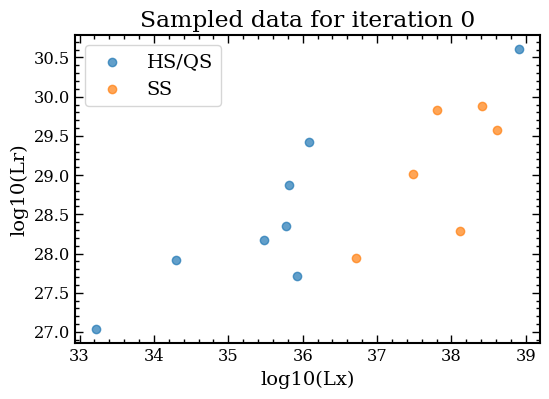

Iteration 2/5: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
p_Lx: 0.09257409257409258 p_Lr: 0.9520479520479521 p_hmp: 0.16874040845988567
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0           4U 1543-47    HS           BH  1.498394e+35  7.965536e+28          False          False
1           4U 1630-47    SS  candidateBH  4.130286e+38  3.727565e+29          False          False
2         EXO 1846-031    SS  candidateBH  9.286800e+36  1.240785e+28          False          False
3         GRS 1739-278    HS  candidateBH  3.763774e+35  3.558757e+28          False          False
4             GX 339-4    HS           BH  2.720213e+37  9.145048e+29          False          False
5            H1743-322    HS  candidateBH  1.314266e+37  2.678335e+29          False          False
6      IGR J17091-3624    SS  candidateBH  4.566031e+37  1.062848e+29          False          False
7       MAXI J1348-630    HS  candidateBH  2.960795e+34  1.98697

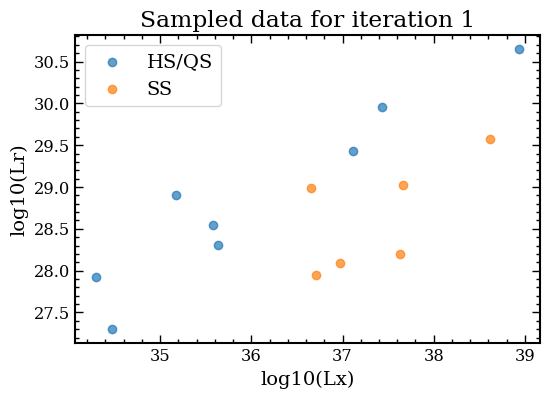

Iteration 3/5: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
p_Lx: 0.0006660006660006659 p_Lr: 0.042624042624042624 p_hmp: 0.0013115090038166959
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0           4U 1543-47    HS           BH  1.205751e+36  2.631691e+29          False          False
1           4U 1630-47    SS  candidateBH  4.412865e+38  5.226694e+29          False          False
2         EXO 1846-031    SS  candidateBH  4.007879e+37  1.675060e+29          False          False
3         GRS 1739-278    SS  candidateBH  2.239153e+37  1.784280e+28          False          False
4             GX 339-4    HS           BH  3.684854e+34  3.028436e+28          False          False
5            H1743-322    HS  candidateBH  1.889867e+36  3.541600e+28          False          False
6      IGR J17091-3624    SS  candidateBH  1.308903e+38  1.701457e+30          False          False
7       MAXI J1348-630    HS  candidateBH  2.960795e+34  1

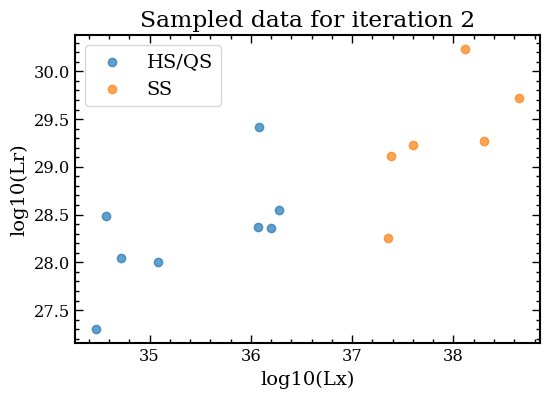

Iteration 4/5: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
p_Lx: 0.042624042624042624 p_Lr: 0.6373626373626372 p_hmp: 0.07990442466446383
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0           4U 1543-47    HS           BH  3.276481e+35  2.838871e+29          False          False
1           4U 1630-47    SS  candidateBH  4.412865e+38  5.226694e+29          False          False
2         EXO 1846-031    SS  candidateBH  4.007879e+37  1.675060e+29          False          False
3         GRS 1739-278    SS  candidateBH  3.041967e+37  1.039196e+29          False          False
4             GX 339-4    SS           BH  6.719570e+37  9.532602e+28          False          False
5            H1743-322    HS  candidateBH  5.616301e+36  9.739400e+28          False          False
6      IGR J17091-3624    SS  candidateBH  1.282257e+38  1.921532e+28          False          False
7       MAXI J1348-630    HS  candidateBH  1.996743e+37  1.0157

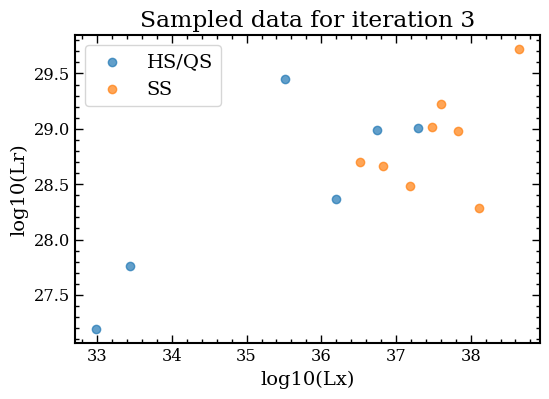

Iteration 5/5: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
p_Lx: 0.004662004662004663 p_Lr: 0.13919413919413917 p_hmp: 0.00902184235517569
                  name state        class            Lx            Lr  Fr_uplim_bool  Fx_uplim_bool
0           4U 1543-47    SS           BH  4.827060e+38  9.573962e+27          False          False
1           4U 1630-47    SS  candidateBH  4.130286e+38  3.727565e+29          False          False
2         EXO 1846-031    SS  candidateBH  4.007879e+37  1.675060e+29          False          False
3         GRS 1739-278    SS  candidateBH  3.041967e+37  1.039196e+29          False          False
4             GX 339-4    HS           BH  5.581047e+35  4.610820e+29          False          False
5            H1743-322    HS  candidateBH  1.889867e+36  3.541600e+28          False          False
6      IGR J17091-3624    SS  candidateBH  4.566031e+37  1.062848e+29          False          False
7       MAXI J1348-630    HS  candidateBH  5.934432e+34  3.262

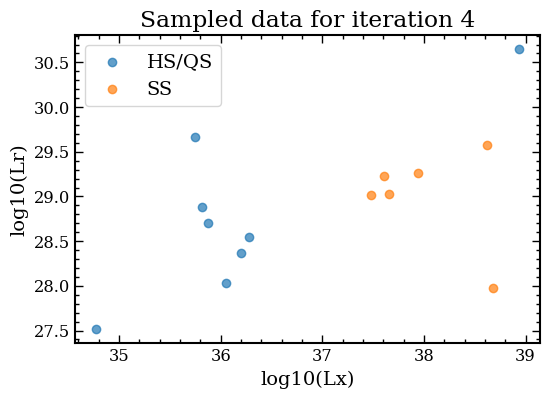

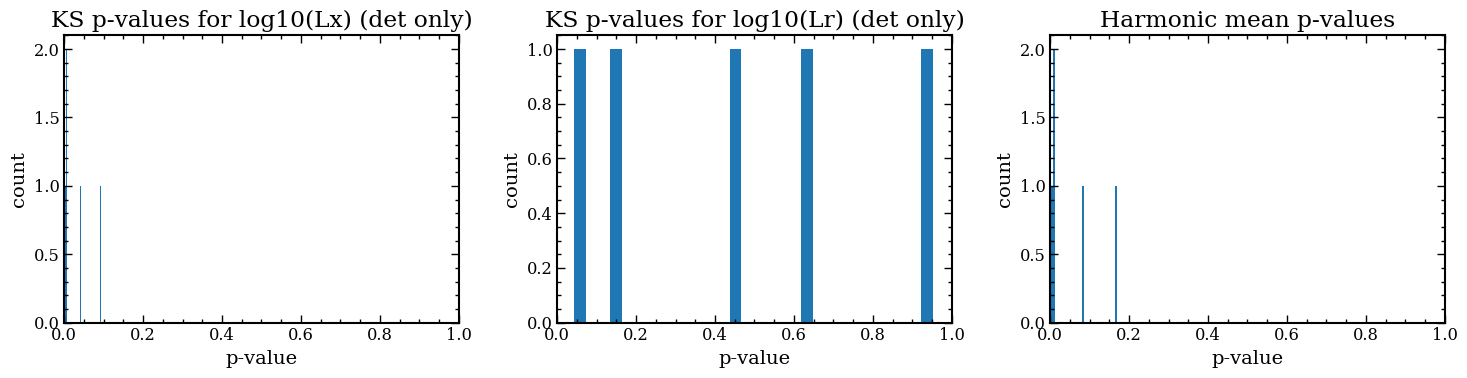


Lx KS
Valid iterations: 5
Fraction with p < 0.05: 80.00%
Fraction with p < 0.01: 60.00%
Fraction with p < 0.001: 20.00%
Median p-value: 4.662e-03
Mean p-value:   2.904e-02

Lr KS
Valid iterations: 5
Fraction with p < 0.05: 20.00%
Fraction with p < 0.01: 0.00%
Fraction with p < 0.001: 0.00%
Median p-value: 4.602e-01
Mean p-value:   4.463e-01

Harmonic mean combined
Valid iterations: 5
Fraction with p < 0.05: 60.00%
Fraction with p < 0.01: 60.00%
Fraction with p < 0.001: 0.00%
Median p-value: 9.231e-03
Mean p-value:   5.364e-02


In [52]:
out = repeated_random_source_sampling_ks(df, n_iter=5, random_seed=None, plot=True)

Iteration 1/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 2/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 3/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 4/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 5/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 6/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 7/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 8/2000: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
Iteration 9/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 10/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 11/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 12/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 13/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 14/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 15/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 16/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False

c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Iteration 494/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 495/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 496/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 497/2000: n1_det=11, n2_det=3, ok_Lx=False, ok_Lr=False
Iteration 498/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 499/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 500/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 501/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 502/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 503/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 504/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 505/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 506/2000: n1_det=11, n2_det=3, ok_Lx=False, ok_Lr=False
Iteration 507/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 508/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 509/2000: n1_det=10, n2_det=4, ok_Lx

c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Iteration 633/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 634/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 635/2000: n1_det=12, n2_det=2, ok_Lx=False, ok_Lr=False
Iteration 636/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 637/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 638/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 639/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 640/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 641/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 642/2000: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
Iteration 643/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 644/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 645/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 646/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 647/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 648/2000: n1_det=8, n2_det=6, ok_

c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Iteration 772/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 773/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 774/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 775/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 776/2000: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
Iteration 777/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 778/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 779/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 780/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 781/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 782/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 783/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 784/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 785/2000: n1_det=11, n2_det=3, ok_Lx=False, ok_Lr=False
Iteration 786/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 787/2000: n1_det=8, n2_det=6, ok_Lx=Tru

c:\Users\justi\OneDrive\Desktop\OXFORD_PROJECT\FINAL_LR_LX_PLANE_ANALYSIS\lrlx_paper_venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


Iteration 1292/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 1293/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1294/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1295/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1296/2000: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
Iteration 1297/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 1298/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1299/2000: n1_det=9, n2_det=5, ok_Lx=True, ok_Lr=True
Iteration 1300/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 1301/2000: n1_det=5, n2_det=9, ok_Lx=True, ok_Lr=True
Iteration 1302/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1303/2000: n1_det=6, n2_det=8, ok_Lx=True, ok_Lr=True
Iteration 1304/2000: n1_det=7, n2_det=7, ok_Lx=True, ok_Lr=True
Iteration 1305/2000: n1_det=8, n2_det=6, ok_Lx=True, ok_Lr=True
Iteration 1306/2000: n1_det=10, n2_det=4, ok_Lx=False, ok_Lr=False
Iteration 1307/2000: n1_det=8, n2_det

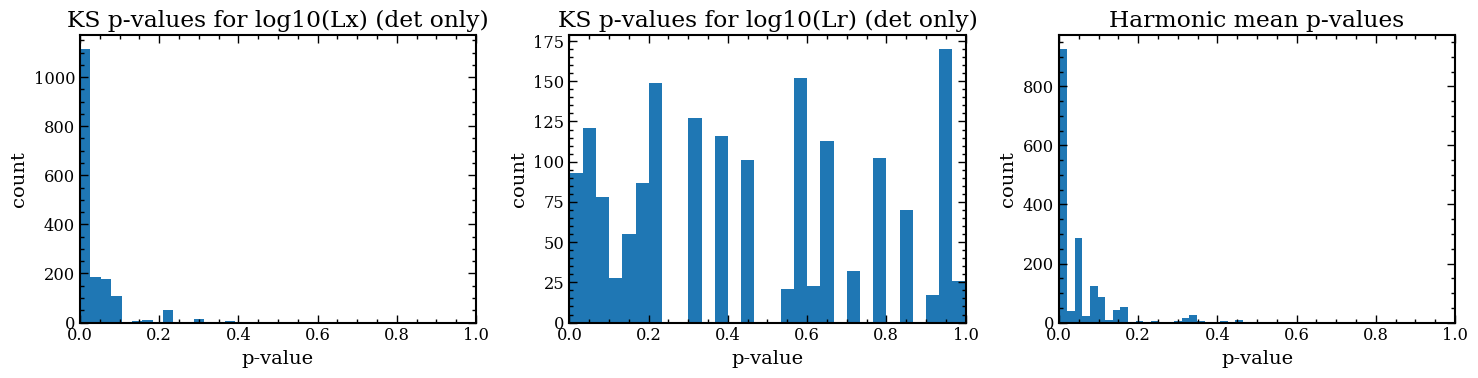


Lx KS
Valid iterations: 1681
Fraction with p < 0.05: 77.33%
Fraction with p < 0.01: 55.09%
Fraction with p < 0.001: 18.02%
Median p-value: 8.159e-03
Mean p-value:   3.391e-02

Lr KS
Valid iterations: 1681
Fraction with p < 0.05: 7.50%
Fraction with p < 0.01: 2.08%
Fraction with p < 0.001: 0.36%
Median p-value: 3.806e-01
Mean p-value:   4.494e-01

Harmonic mean combined
Valid iterations: 1681
Fraction with p < 0.05: 67.88%
Fraction with p < 0.01: 33.37%
Fraction with p < 0.001: 0.30%
Median p-value: 1.609e-02
Mean p-value:   5.503e-02


In [53]:
out = repeated_random_source_sampling_ks(df, n_iter=2000, random_seed=None, plot=False)